In [1]:
import numpy as np
from scipy.io import wavfile
import IPython.display as ipd
from scipy import signal as sig
from scipy.linalg import solve_toeplitz
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
%config InlineBackend.figure_format = 'svg'

import Funciones as Funciones
from NNMF_GIF import NNMF_GIF
from MetricasRendimiento import MetricasRendimiento
import os

# Carga de la señal

In [2]:
with open("Señales Repositorio II Resampleadas/Listas señales/Completa todas.txt", "r") as f:
    archivos = [line.strip() for line in f]
#archivos = archivos[0]

fs_r = 8000
cmap = Funciones.parula_map
color_flujo = 'blue'
color_dflujo = 'red'
color_area = 'orange'
color_darea = 'g'
color_energia = 'magenta'
color_speech = 'black'
legend_loc = 'upper right'



# Definición de parámetros

In [3]:
norma ='fro'
pre_iteraciones = 0
iteraciones     = 6
p_filtro        = 12

# Gráficas

In [4]:
i = 1
iteraciones = []
error_1_fro = []
error_2_fro = []
error_1_ita = []
error_2_ita = []
#archivo = archivos[4]
#os.makedirs("Prueba Repositorio II/Animacion/Frobenius/"+archivo)
itmax = 250
while i < itmax+1:
        iteraciones.append(i)
        e1_fro = []
        e2_fro = []
        e1_ita = []
        e2_ita = []
        for archivo in archivos:
                señales       = np.loadtxt("Señales Repositorio II Resampleadas/"+archivo+".txt", delimiter="\t")
                tiempos_      = señales[:, 0]
                señal_speech_ = señales[:, 1]
                señal_flujo_  = señales[:, 2]
                señal_dflujo_ = señales[:, 3]
                señal_area_   = señales[:, 4]
                señal_darea_  = señales[:, 5]
                to = 750
                tf = 800
                no = int(np.round(to *fs_r/1000)) 
                nf = int(np.round(tf * fs_r/1000))
                tiempos       = tiempos_[no:nf]

                señal_speech  = señal_speech_[no:nf]
                señal_flujo   = señal_flujo_[no:nf]
                señal_dflujo   = señal_dflujo_[no:nf]
                señal_area    = señal_area_[no:nf]
                señal_darea   = señal_darea_[no:nf]

                # frobenius
                SP1 = NNMF_GIF(señal_speech,tiempos,fs_r,norma='fro',pre_iteraciones=pre_iteraciones,iteraciones=pre_iteraciones+i,p_filtro=p_filtro)

                señal_flujo  = señal_flujo[SP1.orden_filtro_tracto-1:len(señal_flujo)-SP1.orden_filtro_tracto-1]
                señal_dflujo = señal_dflujo[SP1.orden_filtro_tracto-1:len(señal_dflujo)-SP1.orden_filtro_tracto-1]


                tiempo_flujo1,_,flujo1 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_flujo,SP1.flujo1)
                tiempo_flujo2,_,flujo2 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_flujo,SP1.flujo2)

                tiempo_dflujo1,señal_dflujo_1,dflujo1 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_dflujo,SP1.dflujo1)
                tiempo_dflujo2,señal_dflujo_2,dflujo2 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_dflujo,SP1.dflujo2)

                MR1 = MetricasRendimiento(señal_dflujo_1,Funciones.Escalar(dflujo1,señal_dflujo_1),fs_r,tiempo_dflujo1)
                MR2 = MetricasRendimiento(señal_dflujo_2,Funciones.Escalar(dflujo2,señal_dflujo_2),fs_r,tiempo_dflujo2)
                e1_fro.append(MR1.Error)
                e2_fro.append(MR2.Error)
                # itakura-saito
                tiempos       = tiempos_[no:nf]

                señal_speech  = señal_speech_[no:nf]
                señal_flujo   = señal_flujo_[no:nf]
                señal_dflujo   = señal_dflujo_[no:nf]
                señal_area    = señal_area_[no:nf]
                señal_darea   = señal_darea_[no:nf]
                
                SP1 = NNMF_GIF(señal_speech,tiempos,fs_r,norma='itakura-saito',pre_iteraciones=pre_iteraciones,iteraciones=pre_iteraciones+i,p_filtro=p_filtro)
                señal_flujo  = señal_flujo[SP1.orden_filtro_tracto-1:len(señal_flujo)-SP1.orden_filtro_tracto-1]
                señal_dflujo = señal_dflujo[SP1.orden_filtro_tracto-1:len(señal_dflujo)-SP1.orden_filtro_tracto-1]


                tiempo_flujo1,_,flujo1 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_flujo,SP1.flujo1)
                tiempo_flujo2,_,flujo2 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_flujo,SP1.flujo2)

                tiempo_dflujo1,señal_dflujo_1,dflujo1 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_dflujo,SP1.dflujo1)
                tiempo_dflujo2,señal_dflujo_2,dflujo2 = Funciones.Sincronizar2(SP1.tiempos_gve,señal_dflujo,SP1.dflujo2)

                MR1 = MetricasRendimiento(señal_dflujo_1,Funciones.Escalar(dflujo1,señal_dflujo_1),fs_r,tiempo_dflujo1)
                MR2 = MetricasRendimiento(señal_dflujo_2,Funciones.Escalar(dflujo2,señal_dflujo_2),fs_r,tiempo_dflujo2)
                e1_ita.append(MR1.Error)
                e2_ita.append(MR2.Error)
        i+=1
        error_1_fro.append(np.array(e1_fro))
        error_2_fro.append(np.array(e2_fro))
        error_1_ita.append(np.array(e1_ita))
        error_2_ita.append(np.array(e2_ita))


In [8]:
mediana_1_fro = np.zeros(itmax)
p25_1_fro     = np.zeros(itmax)
p75_1_fro     =np.zeros(itmax)

mediana_2_fro = np.zeros(itmax)
p25_2_fro     = np.zeros(itmax)
p75_2_fro     =np.zeros(itmax)

mediana_1_ita = np.zeros(itmax)
p25_1_ita     = np.zeros(itmax) 
p75_1_ita     =np.zeros(itmax)

mediana_2_ita = np.zeros(itmax)
p25_2_ita     = np.zeros(itmax)
p75_2_ita     =np.zeros(itmax)

for i in range(itmax):
    mediana_1_fro[i] = np.median(error_1_fro[i])
    p25_1_fro[i] = np.percentile(error_1_fro[i], 25)
    p75_1_fro[i] = np.percentile(error_1_fro[i], 75)

    mediana_2_fro[i] = np.median(error_2_fro[i])
    p25_2_fro[i] = np.percentile(error_2_fro[i], 25)
    p75_2_fro[i] = np.percentile(error_2_fro[i], 75)


    mediana_1_ita[i] = np.median(error_1_ita[i])
    p25_1_ita[i] = np.percentile(error_1_ita[i], 25)
    p75_1_ita[i] = np.percentile(error_1_ita[i], 75)

    mediana_2_ita[i] = np.median(error_2_ita[i])
    p25_2_ita[i] = np.percentile(error_2_ita[i], 25)
    p75_2_ita[i] = np.percentile(error_2_ita[i], 75)



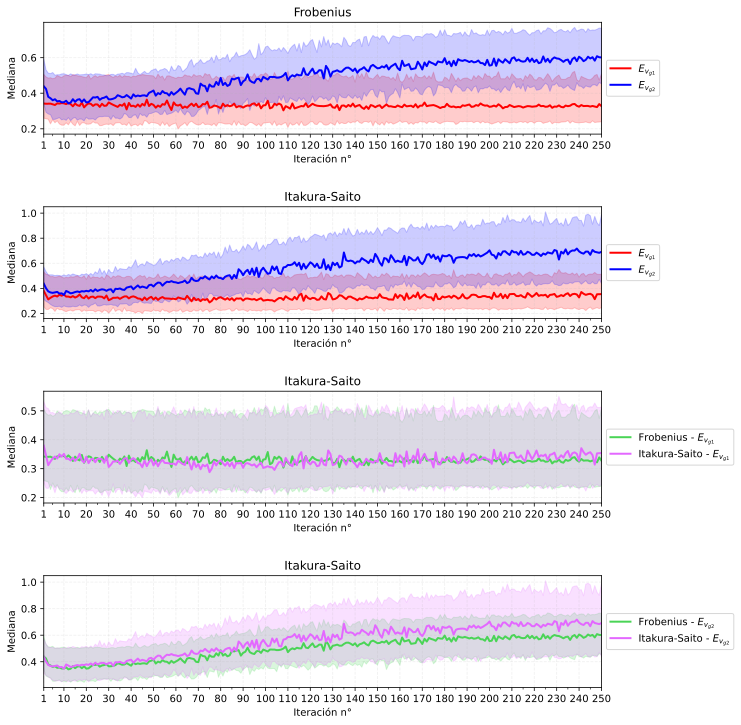

In [22]:
fig,ax = plt.subplots(4,1,figsize=(10,12))
# Mayor separación vertical entre subplots
plt.subplots_adjust(hspace=0.65)

iter   = np.arange(1,itmax+1)
color1= (1, 0, 0)
color2 = (0, 0, 1)
color_fro= (0.29, 0.831, 0.337)
color_ita = (0.89, 0.408, 1)


alpha =0.2 
ax[0].plot(iter,mediana_1_fro,linewidth=2,color=color1,label=r"$E_{v_{g1}}$")
ax[0].fill_between(iter,p25_1_fro, p75_1_fro,color=color1,alpha=alpha);
ax[0].plot(iter,mediana_2_fro,linewidth=2,color=color2,label=r"$E_{v_{g2}}$")
ax[0].fill_between(iter,p25_2_fro, p75_2_fro,color=color2,alpha=alpha);
ax[0].set_xlabel("Iteración n°")
ticks_mayores = [1] + list(range(10, itmax+1, 10))
ticks_menores = np.arange(5, itmax, 10)
ax[0].set_xlim(1, itmax)
ax[0].set_xticks(ticks_mayores)
ax[0].set_xticks(ticks_menores, minor=True)
ax[0].grid(True,linestyle='dashed',alpha=0.2)
ax[0].set_ylabel("Mediana")
ax[0].set_title("Frobenius")

ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax[1].plot(iter,mediana_1_ita,linewidth=2,color=color1,label=r"$E_{v_{g1}}$")
ax[1].fill_between(iter,p25_1_ita, p75_1_ita,color=color1,alpha=alpha);
ax[1].plot(iter,mediana_2_ita,linewidth=2,color=color2,label=r"$E_{v_{g2}}$")
ax[1].fill_between(iter,p25_2_ita, p75_2_ita,color=color2,alpha=alpha);
ax[1].set_xlabel("Iteración n°")
ax[1].set_ylabel("Mediana")
ax[1].set_title("Itakura-Saito")
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ticks_mayores = [1] + list(range(10, itmax+1, 10))
ticks_menores = np.arange(5, itmax, 10)
ax[1].set_xlim(1, itmax)
ax[1].set_xticks(ticks_mayores)
ax[1].set_xticks(ticks_menores, minor=True)
ax[1].grid(True,linestyle='dashed',alpha=0.2)

# EVG1 FRO E ITA
ax[2].plot(iter,mediana_1_fro,linewidth=2,color=color_fro,label=r"Frobenius - $E_{v_{g1}}$")
ax[2].fill_between(iter,p25_1_fro, p75_1_fro,color=color_fro,alpha=alpha);
ax[2].plot(iter,mediana_1_ita,linewidth=2,color=color_ita,label=r"Itakura-Saito - $E_{v_{g1}}$")
ax[2].fill_between(iter,p25_1_ita, p75_1_ita,color=color_ita,alpha=alpha);
ax[2].set_xlabel("Iteración n°")
ax[2].set_ylabel("Mediana")
ax[2].set_title("Itakura-Saito")
ax[2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ticks_mayores = [1] + list(range(10, itmax+1, 10))
ticks_menores = np.arange(5, itmax, 10)
ax[2].set_xlim(1, itmax)
ax[2].set_xticks(ticks_mayores)
ax[2].set_xticks(ticks_menores, minor=True)
ax[2].grid(True,linestyle='dashed',alpha=0.2)

# EVG2 FRO E ITA
ax[3].plot(iter,mediana_2_fro,linewidth=2,color=color_fro,label=r"Frobenius - $E_{v_{g2}}$")
ax[3].fill_between(iter,p25_2_fro, p75_2_fro,color=color_fro,alpha=alpha);
ax[3].plot(iter,mediana_2_ita,linewidth=2,color=color_ita,label=r"Itakura-Saito - $E_{v_{g2}}$")
ax[3].fill_between(iter,p25_2_ita, p75_2_ita,color=color_ita,alpha=alpha);
ax[3].set_xlabel("Iteración n°")
ax[3].set_ylabel("Mediana")
ax[3].set_title("Itakura-Saito")
ax[3].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ticks_mayores = [1] + list(range(10, itmax+1, 10))
ticks_menores = np.arange(5, itmax, 10)
ax[3].set_xlim(1, itmax)
ax[3].set_xticks(ticks_mayores)
ax[3].set_xticks(ticks_menores, minor=True)
ax[3].grid(True,linestyle='dashed',alpha=0.2)

# ===============================  Recuadro con los parámetros del modelo ==============================================================================================
#fig.suptitle("Todas las señales | p = 12 | pre-iteraciones = 0")
fig.savefig("Prueba Repositorio II/Error_iteracion_2.pdf",bbox_inches = 'tight');
